In [1]:
!date

Thu Sep 17 10:46:40 PDT 2026


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
figdir = f'{projdir}/figures/pmds'
outdir = f'{projdir}/results/qc/data/qc14'
!mkdir -p {outdir}
classes = ['never', 'rare', 'variable', 'common', 'constitutive']

### inputs: donor x 10kb bin matrix (B01b), domain classes, per-bin variance (B03a), donor metrics (QC13)

In [4]:
z = np.load(f'{projdir}/results/meth_bins/donor_bin_meth_10kb.npz', allow_pickle=True)
meth, donors = z['meth'], list(z['donors'])
freq = pd.read_csv(f'{projdir}/results/meth_bins/domain_frequency_10kb.tsv.gz', sep='\t')
bv = pd.read_csv(f'{projdir}/results/meth_bins/qc_genetics/bin_variance_10kb.tsv.gz', sep='\t')
dm = pd.read_csv(f'{projdir}/results/qc/data/qc13/donor_pmd_expansion_metrics.tsv', sep='\t').set_index('sample').loc[donors].reset_index()
meth.shape, freq.shape, bv.shape, dm.shape

((201, 265052), (265052, 14), (265052, 11), (201, 29))

In [5]:
bv.head()

,chrom,bin_start,class_pmd,class_rel,n_mqtl,n_tss,v_between,v_within,r2_state,r2_state_chem,r2_chem
0,chr1,690000,never,never,7.0,0.0,0.00387,0.00165,NaN,NaN,NaN
1,chr1,700000,never,rare,0.0,0.0,0.00531,0.00289,NaN,NaN,NaN
2,chr1,710000,never,never,3.0,0.0,0.00110,0.00103,NaN,NaN,NaN
3,chr1,720000,never,never,9.0,0.0,0.00020,0.00009,NaN,NaN,NaN
4,chr1,730000,never,never,0.0,0.0,0.00009,0.00011,NaN,NaN,NaN


### annotate bins: CGI, gene body, TSS, CpG count, distance to nearest constitutive domain

In [6]:
cgi = pd.read_csv('/u/project/cluo/terencew/reference/hg38/bed/cpgIslandExt.hg38.bed', sep='\t', header=None, usecols=[0, 1, 2])
genes = pd.read_csv('/u/project/cluo/terencew/reference/hg38_igvf/bed/genes/gencode.v43.autosome.dedup.names.bed.gz', sep='\t', header=None, usecols=[0, 1, 2])
tss = pd.read_csv(f'{projdir}/reference/hprc2/gencode_v43_autosome_gene_tss.bed', sep='\t', header=None, usecols=[0, 1, 4])
tss = tss[tss[4].isin(['protein_coding', 'lncRNA'])]

def bin_overlap_bp(iv):
    out = {}
    for c, s, e in zip(iv[0], iv[1], iv[2]):
        for b in range((s // 10000) * 10000, e, 10000):
            out[(c, b)] = out.get((c, b), 0) + min(e, b + 10000) - max(s, b)
    return out

key = list(zip(freq['chrom'], freq['bin_start']))
ann = freq[['chrom', 'bin_start', 'class_pmd', 'mean_meth', 'sd_meth']].copy()
cg = bin_overlap_bp(cgi)
ann['cgi_bp'] = [cg.get(k, 0) for k in key]
gb = bin_overlap_bp(genes)
ann['gene_bp'] = [min(gb.get(k, 0), 10000) for k in key]
tn = tss.assign(b=(tss[1] // 10000) * 10000).groupby([0, 'b']).size().to_dict()
ann['n_tss'] = [tn.get(k, 0) for k in key]
ann['annot'] = np.select([ann['n_tss'] > 0, ann['cgi_bp'] > 0, ann['gene_bp'] >= 5000], ['TSS', 'CGI (no TSS)', 'gene body'], 'intergenic')

In [7]:
dist = np.full(len(ann), np.inf)
for c, g in ann.groupby('chrom'):
    cs = np.sort(g.loc[g['class_pmd'] == 'constitutive', 'bin_start'].values)
    if not len(cs):
        continue
    p = g['bin_start'].values
    i = np.clip(np.searchsorted(cs, p), 1, len(cs) - 1)
    dist[g.index] = np.minimum(np.abs(p - cs[i - 1]), np.abs(p - cs[i]))
ann['dist_const_kb'] = dist / 1000
ann['dist_class'] = pd.cut(ann['dist_const_kb'], [-1, 0, 50, 200, 1000, 5000, np.inf],
                           labels=['inside', '10-50kb', '60-200kb', '0.2-1Mb', '1-5Mb', '>5Mb'])
ann = ann.merge(bv[['chrom', 'bin_start', 'v_between', 'v_within', 'r2_state', 'r2_state_chem']], on=['chrom', 'bin_start'])

In [8]:
ann.head()

,chrom,bin_start,class_pmd,mean_meth,sd_meth,cgi_bp,gene_bp,n_tss,annot,dist_const_kb,dist_class,v_between,v_within,r2_state,r2_state_chem
0,chr1,690000,never,0.6329,0.0621,0,10000,0,gene body,1900.0,1-5Mb,0.00387,0.00165,NaN,NaN
1,chr1,700000,never,0.6579,0.0722,0,10000,0,gene body,1890.0,1-5Mb,0.00531,0.00289,NaN,NaN
2,chr1,710000,never,0.8713,0.0330,0,10000,0,gene body,1880.0,1-5Mb,0.00110,0.00103,NaN,NaN
3,chr1,720000,never,0.9155,0.0141,0,10000,0,gene body,1870.0,1-5Mb,0.00020,0.00009,NaN,NaN
4,chr1,730000,never,0.9352,0.0093,0,10000,0,gene body,1860.0,1-5Mb,0.00009,0.00011,NaN,NaN


In [9]:
ann['annot'].value_counts()

gene body       139682
intergenic       87118
TSS              29201
CGI (no TSS)      9051
Name: annot, dtype: int64

### 1. how much of the between-line variance sits in domains

In [10]:
ann['v_state'] = ann['v_between'] * ann['r2_state']
share = ann.groupby('class_pmd').agg(n_bins=('v_between', 'size'), v_total=('v_between', 'sum'), v_state=('v_state', 'sum')).reindex(classes)
share['frac_bins'] = share['n_bins'] / share['n_bins'].sum()
share['frac_of_total_variance'] = share['v_total'] / share['v_total'].sum()
share['frac_of_state_variance'] = share['v_state'] / share['v_state'].sum()
share['state_explained_within_class'] = share['v_state'] / share['v_total']
share.round(3)

,n_bins,v_total,v_state,frac_bins,frac_of_total_variance,frac_of_state_variance,state_explained_within_class
class_pmd,,,,,,,
never,82515,81.648,37.927,0.311,0.097,0.063,0.465
rare,39526,119.524,78.903,0.149,0.142,0.132,0.660
variable,28167,107.236,75.149,0.106,0.127,0.125,0.701
common,7340,29.594,21.649,0.028,0.035,0.036,0.732
constitutive,107504,504.768,385.593,0.406,0.599,0.643,0.764


### 2. does outside-domain mCG move with domain depth (and is it nonlinear)

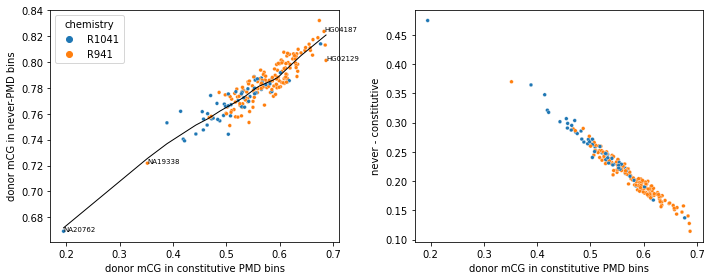

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(data=dm, x='mcg_constitutive', y='mcg_never', hue='chemistry', s=14, ax=axes[0])
lw = sm.nonparametric.lowess(dm['mcg_never'], dm['mcg_constitutive'], frac=0.4)
axes[0].plot(lw[:, 0], lw[:, 1], c='k', lw=1)
for s in ['NA20762', 'NA19338', 'HG04187', 'HG02129']:
    r = dm[dm['sample'] == s]
    axes[0].annotate(s, (r['mcg_constitutive'].iloc[0], r['mcg_never'].iloc[0]), fontsize=7)
axes[0].set_xlabel('donor mCG in constitutive PMD bins')
axes[0].set_ylabel('donor mCG in never-PMD bins')
sns.scatterplot(data=dm, x='mcg_constitutive', y='depth_constitutive', hue='chemistry', s=14, ax=axes[1], legend=False)
axes[1].set_xlabel('donor mCG in constitutive PMD bins')
axes[1].set_ylabel('never - constitutive')
plt.tight_layout()
plt.savefig(f'{figdir}/qc14_inside_vs_outside_domains.png', dpi=150)

In [12]:
rows = []
for lo, hi in [(0, 0.5), (0.5, 0.6), (0.6, 1)]:
    d = dm[(dm['mcg_constitutive'] >= lo) & (dm['mcg_constitutive'] < hi)]
    if len(d) < 3:
        rows.append({'range': f'{lo}-{hi}', 'n': len(d)})
        continue
    f = smf.ols('mcg_never ~ mcg_constitutive + C(chemistry)', d).fit() if d['chemistry'].nunique() > 1 else smf.ols('mcg_never ~ mcg_constitutive', d).fit()
    rows.append({'range': f'{lo}-{hi}', 'n': len(d), 'slope_never_on_const': f.params['mcg_constitutive'], 'p': f.pvalues['mcg_constitutive'],
                 'mean_never': d['mcg_never'].mean(), 'sd_never': d['mcg_never'].std()})
seg = pd.DataFrame(rows)
seg

,range,n,slope_never_on_const,p,mean_never,sd_never
0,0-0.5,26,0.299828,1.792683e-10,0.753514,0.020884
1,0.5-0.6,117,0.257657,1.399788e-19,0.777372,0.010328
2,0.6-1,58,0.333363,4.276791e-11,0.800294,0.010859


In [13]:
# global: never-bin mCG vs constitutive mCG, chemistry adjusted, with a quadratic term for curvature
f1 = smf.ols('mcg_never ~ mcg_constitutive + C(chemistry)', dm).fit()
f2 = smf.ols('mcg_never ~ mcg_constitutive + I(mcg_constitutive**2) + C(chemistry)', dm).fit()
print(f1.params.round(3).to_dict(), 'R2', round(f1.rsquared, 3))
print(f2.params.round(3).to_dict(), 'R2', round(f2.rsquared, 3), 'curvature p', f2.compare_f_test(f1)[1])

{'Intercept': 0.627, 'C(chemistry)[T.R941]': -0.0, 'mcg_constitutive': 0.274} R2 0.842
{'Intercept': 0.628, 'C(chemistry)[T.R941]': -0.0, 'mcg_constitutive': 0.269, 'I(mcg_constitutive ** 2)': 0.005} R2 0.842 curvature p 0.9340194447137697


In [14]:
# same without the 2 extreme donors
d = dm[~dm['sample'].isin(['NA20762', 'NA19338'])]
f3 = smf.ols('mcg_never ~ mcg_constitutive + C(chemistry)', d).fit()
print(f3.params.round(3).to_dict(), 'R2', round(f3.rsquared, 3), 'p', f3.pvalues['mcg_constitutive'])

{'Intercept': 0.632, 'C(chemistry)[T.R941]': -0.0, 'mcg_constitutive': 0.266} R2 0.8 p 1.4234379336989434e-62


### 3. where the state-linked variance outside domains lives

In [15]:
nv = ann[ann['class_pmd'] == 'never']
t1 = nv.groupby('dist_class').agg(n=('v_between', 'size'), mean_mcg=('mean_meth', 'median'), v_between=('v_between', 'median'),
                                  r2_state=('r2_state', 'median'))
t1

,n,mean_mcg,v_between,r2_state
dist_class,,,,
inside,0,NaN,NaN,NaN
10-50kb,1728,0.89705,0.00027,0.195550
60-200kb,6837,0.86270,0.00048,0.266340
0.2-1Mb,26423,0.83830,0.00063,0.327505
1-5Mb,40379,0.82020,0.00072,0.361210
>5Mb,7148,0.78460,0.00079,0.395410


In [16]:
t2 = ann.groupby(['class_pmd', 'annot']).agg(n=('v_between', 'size'), mean_mcg=('mean_meth', 'median'), v_between=('v_between', 'median'),
                                             r2_state=('r2_state', 'median'), v_within=('v_within', 'median')).reindex(classes, level=0)
t2

n  mean_mcg  v_between  r2_state  v_within
class_pmd    annot                                                       
never        CGI (no TSS)   4893   0.71600   0.000950  0.408940   0.00021
             TSS           14858   0.57170   0.001020  0.421800   0.00018
             gene body     50176   0.88120   0.000360  0.218275   0.00020
             intergenic    12588   0.77610   0.001310  0.681245   0.00027
rare         CGI (no TSS)   2026   0.59940   0.002260  0.732560   0.00035
             TSS            5409   0.60710   0.002360  0.692560   0.00037
             gene body     20345   0.69490   0.003110  0.791420   0.00047
             intergenic    11746   0.67140   0.003160  0.870285   0.00043
variable     CGI (no TSS)    891   0.60150   0.002630  0.758970   0.00038
             TSS            2728   0.58630   0.003020  0.773280   0.00043
             gene body     14755   0.64410   0.003920  0.868110   0.00052
             intergenic     9793   0.63090   0.003880  0.895400   0.00049
common       CGI (no TSS)    145   0.63140   0.002760  0.709625   0.00040
             TSS             560   0.57900   0.003225  0.815480   0.00043
             gene body      4158   0.62265   0.004120  0.883170   0.00053
             intergenic     2477   0.61730   0.004090  0.893350   0.00051
constitutive CGI (no TSS)   1096   0.55620   0.003160  0.743960   0.00047
             TSS            5646   0.55690   0.004270  0.903380   0.00052
             gene body     50248   0.56830   0.004740  0.914490   0.00055
             intergenic    50514   0.55820   0.004810  0.915565   0.00056

In [17]:
nv = nv.assign(mcg_class=pd.cut(nv['mean_meth'], [0, 0.4, 0.6, 0.7, 0.8, 1.0]))
t3 = nv.groupby('mcg_class').agg(n=('v_between', 'size'), v_between=('v_between', 'median'), r2_state=('r2_state', 'median'))
t3

,n,v_between,r2_state
mcg_class,,,
"(0.0, 0.4]",3565,0.00140,0.377930
"(0.4, 0.6]",7210,0.00105,0.441585
"(0.6, 0.7]",7657,0.00212,0.715040
"(0.7, 0.8]",16541,0.00160,0.666580
"(0.8, 1.0]",47542,0.00027,0.198890


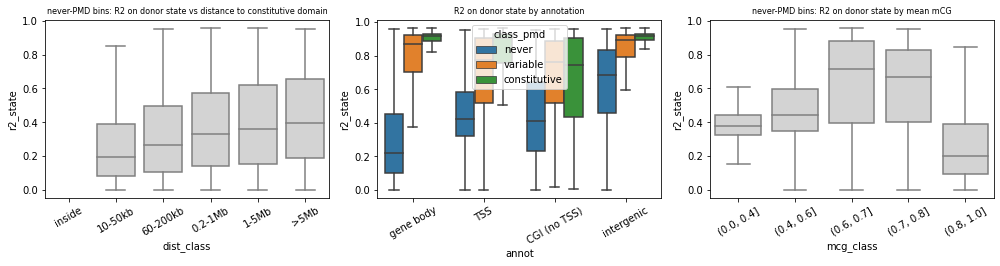

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
sns.boxplot(data=nv, x='dist_class', y='r2_state', fliersize=0, ax=axes[0], color='lightgray')
axes[0].set_title('never-PMD bins: R2 on donor state vs distance to constitutive domain', fontsize=8)
sns.boxplot(data=ann, x='annot', y='r2_state', hue='class_pmd', hue_order=['never', 'variable', 'constitutive'], fliersize=0, ax=axes[1])
axes[1].set_title('R2 on donor state by annotation', fontsize=8)
sns.boxplot(data=nv, x='mcg_class', y='r2_state', fliersize=0, ax=axes[2], color='lightgray')
axes[2].set_title('never-PMD bins: R2 on donor state by mean mCG', fontsize=8)
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{figdir}/qc14_state_variance_outside_domains.png', dpi=150)

### 4. residual variance after removing donor state + chemistry: what structure is left outside domains

In [19]:
idx_never = np.flatnonzero(freq['class_pmd'].values == 'never')
X = np.column_stack([np.ones(len(donors)), dm['depth_constitutive'], (dm['chemistry'] == 'R1041').astype(float)])
Y = meth[:, idx_never]
ok = ~np.isnan(Y).any(axis=0)
Y = Y[:, ok]
beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
R = Y - X @ beta
u, s, vt = np.linalg.svd(R - R.mean(axis=0), full_matrices=False)
var = s ** 2 / (s ** 2).sum()
pcs = pd.DataFrame(u[:, :5] * s[:5], columns=[f'rPC{i + 1}' for i in range(5)])
pcs['sample'] = donors
var[:10].round(3)

array([0.275, 0.102, 0.062, 0.036, 0.02 , 0.018, 0.015, 0.013, 0.011,
       0.011])

In [20]:
pc = pcs.merge(dm, on='sample')
rows = []
for p in [f'rPC{i + 1}' for i in range(5)]:
    for c, t in [('superpopulation', 'C(superpopulation)'), ('sex', 'C(sex)'), ('id_prefix', 'C(id_prefix)'), ('passage', 'passage'),
                 ('established', 'C(established)'), ('mean_depth', 'mean_depth'), ('read_N50_ont', 'read_N50_ont'), ('global_meth', 'global_meth')]:
        d = pc.dropna(subset=[c])
        r = smf.ols(f'{p} ~ {t}', d).fit()
        rows.append({'pc': p, 'covariate': c, 'r2': r.rsquared, 'p': r.f_pvalue})
rp = pd.DataFrame(rows)
rp.pivot(index='covariate', columns='pc', values='r2').round(3)

pc,rPC1,rPC2,rPC3,rPC4,rPC5
covariate,,,,,
established,0.023,0.031,0.075,0.003,0.009
global_meth,0.011,0.050,0.063,0.000,0.126
id_prefix,-0.000,0.000,0.000,-0.000,0.000
mean_depth,0.010,0.008,0.018,0.001,0.003
passage,0.000,0.000,0.000,0.001,0.012
read_N50_ont,0.000,0.000,0.014,0.017,0.011
sex,0.008,0.004,0.058,0.001,0.000
superpopulation,0.044,0.072,0.064,0.143,0.044


In [21]:
# which never bins load on residual PC1
load = pd.DataFrame({'chrom': freq['chrom'].values[idx_never][ok], 'bin_start': freq['bin_start'].values[idx_never][ok], 'rPC1': vt[0]})
load = load.merge(ann[['chrom', 'bin_start', 'annot', 'dist_class', 'mean_meth']], on=['chrom', 'bin_start'])
load['abs_load'] = load['rPC1'].abs()
load.groupby('chrom')['abs_load'].mean().sort_values(ascending=False).head(8)

chrom
chr19    0.003417
chr22    0.003406
chr20    0.003372
chr16    0.003295
chr21    0.003262
chr17    0.003229
chr11    0.003139
chr6     0.003136
Name: abs_load, dtype: float64

In [22]:
load.groupby('annot')['abs_load'].mean()

annot
CGI (no TSS)    0.003242
TSS             0.003365
gene body       0.002793
intergenic      0.003862
Name: abs_load, dtype: float64

### write outputs

In [23]:
share.to_csv(f'{outdir}/variance_share_by_domain_class.tsv', sep='\t')
seg.to_csv(f'{outdir}/never_vs_constitutive_segments.tsv', sep='\t', index=False)
t1.to_csv(f'{outdir}/never_bins_by_distance.tsv', sep='\t')
t2.to_csv(f'{outdir}/bins_by_class_and_annotation.tsv', sep='\t')
rp.to_csv(f'{outdir}/residual_pc_covariates.tsv', sep='\t', index=False)
ann.to_csv(f'{outdir}/bin_annotation_variance_10kb.tsv.gz', sep='\t', index=False)

In [24]:
!date

Thu Sep 17 10:47:17 PDT 2026
